In [1]:
# --- Environment Setup ---
import os
from pathlib import Path

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CHE1148/project_code/CHE1148_Defect_Detecting")
LOCAL_PROJECT_ROOT = Path(r"C:\Download\Pycharm code\CHE1148_Defect_Detecting")

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    PROJECT_ROOT = COLAB_PROJECT_ROOT
    runtime_mode = "colab_drive"
else:
    PROJECT_ROOT = LOCAL_PROJECT_ROOT
    runtime_mode = "local"

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print(f"Runtime mode: {runtime_mode}")
print(f"Working directory: {os.getcwd()}")

Runtime mode: local
Working directory: C:\Download\Pycharm code\CHE1148_Defect_Detecting


In [2]:
# --- Core Imports ---
# Standard libraries, ML stack, and optional add-ons.
import copy
import hashlib
import json
import math
import os
import random
import warnings
from collections import defaultdict
from collections.abc import Sized
from pathlib import Path
from typing import Dict, List, Optional, Tuple, TypedDict

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm.auto import tqdm
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import torchinfo
except ImportError:
    torchinfo = None

try:
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz
except ImportError:
    IntegratedGradients = None
    viz = None


In [3]:
# --- Paths and Device Setup ---
import torch
import random
import numpy as np
import os
from pathlib import Path
import pandas as pd

IN_COLAB = bool(globals().get("IN_COLAB", False))
ROOT = Path(globals().get("PROJECT_ROOT", r"C:\Download\Pycharm code\CHE1148_Defect_Detecting"))
DATA_ROOT = ROOT / "data"

if not ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {ROOT}")
if not DATA_ROOT.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

os.chdir(ROOT)

# Data directory structure
RAW = DATA_ROOT / "raw" / "textile"
PROCESSED = DATA_ROOT / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path(r"C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File path definitions
TRAIN_H5, TRAIN_CSV = RAW / "train64.h5", RAW / "train64.csv"
TEST_H5, TEST_CSV = RAW / "test64.h5", RAW / "test64.csv"
OUT_H5, OUT_CSV = PROCESSED / "full64.h5", PROCESSED / "full64.csv"
TRAIN_SPLIT_CSV = PROCESSED / "train_split.csv"
VAL_SPLIT_CSV = PROCESSED / "val_split.csv"
TEST_SPLIT_CSV = PROCESSED / "test_split.csv"

# Path utilities
def _require_file(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

def _normalize_label(x) -> str:
    return str(x).strip()

def print_class_counts(df: pd.DataFrame, title: str) -> None:
    if "indication_type" not in df.columns:
        return
    vc = df["indication_type"].astype(str).str.strip().value_counts()
    print(f"\n[{title}] total_images={len(df)}")
    for k, v in vc.items():
        print(f"  {k}: {v}")

# Device and Runtime info
# Keep False by default for local compatibility. If you need hard CUDA, set True manually.
REQUIRE_CUDA = False
def select_device(require_cuda: bool = False):
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        return torch.device("cuda"), f"cuda ({torch.cuda.get_device_name(0)})"
    if require_cuda: raise RuntimeError("CUDA unavailable")
    return torch.device("cpu"), "cpu"

GLOBAL_SEED = 42

def set_seed(seed: int = GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

device, device_name = select_device(require_cuda=REQUIRE_CUDA)
set_seed(GLOBAL_SEED)
print(f"Using device: {device_name}")

Using device: cpu


In [4]:
# --- Global Training and Evaluation Config ---
FULL_CLASSES = ["good", "color", "cut", "hole", "thread", "metal_contamination"]

DEFAULT_NUM_WORKERS = 2 if bool(globals().get("IN_COLAB", False)) else 0

TRAIN_CFG = {
    "batch": 512,
    "epochs": 30,
    "patience": 5,
    "num_workers": DEFAULT_NUM_WORKERS,
}

# --- Global Optimizer Configuration ---
OPTIM_CFG = {
    "name": "adam",
    "lr": 0.001,
    "foreach": False,
}

BASELINE_SCENARIO = "all_training"

# --- Global Evaluation Configuration ---
EVAL_CFG = {
    "f1_average": "macro",
    "auprc_average": "macro",
    "zero_division": 0,
    "early_stop_metric": "f1",
    "early_stop_mode": "max",
}

In [5]:
# --- Data Merge Utilities ---
def merge_data() -> None:
    """Merges raw train/test H5 and CSV files into a unified dataset."""
    if OUT_H5.exists() and OUT_CSV.exists():
        print("Dataset already merged.")
        return

    _require_file(TRAIN_CSV); _require_file(TEST_CSV)
    _require_file(TRAIN_H5); _require_file(TEST_H5)

    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)
    df_train["original_split"], df_test["original_split"] = "train", "test"

    full_df = pd.concat([df_train, df_test], ignore_index=True)
    full_df.to_csv(OUT_CSV, index=False)

    with h5py.File(OUT_H5, "w") as f_out:
        with h5py.File(TRAIN_H5, "r") as f_tr, h5py.File(TEST_H5, "r") as f_te:
            tr_imgs, te_imgs = f_tr["images"], f_te["images"]
            dset = f_out.create_dataset("images", shape=(len(tr_imgs)+len(te_imgs), *tr_imgs.shape[1:]), dtype="f")
            dset[:len(tr_imgs)] = tr_imgs[:]
            dset[len(tr_imgs):] = te_imgs[:]
    print(f"Merged data saved to: {OUT_H5}")

In [6]:
# --- Duplicate and Leakage Checks ---
def get_h5_hashes(h5_path: Path, total_images: int, chunk_size: int = 5000) -> List[str]:
    """Generates MD5 fingerprints for images in H5 file chunks."""
    hashes = [""] * total_images
    with h5py.File(h5_path, "r") as f:
        imgs = f["images"]
        for start in range(0, total_images, chunk_size):
            end = min(start + chunk_size, total_images)
            chunk = imgs[start:end]
            for i, img in enumerate(chunk):
                hashes[start + i] = hashlib.md5(img.tobytes()).hexdigest()
    return hashes

def analyze_duplicates() -> List[str]:
    """Identifies duplicate images and checks for split leakage."""
    df = pd.read_csv(OUT_CSV)
    with h5py.File(OUT_H5, "r") as f:
        total = int(f["images"].shape[0])

    all_hashes = get_h5_hashes(OUT_H5, total)
    hash_map = defaultdict(list)
    for idx, h in enumerate(all_hashes): hash_map[h].append(idx)

    dups = {h: idxs for h, idxs in hash_map.items() if len(idxs) > 1}
    if dups:
        dup_indices = [i for idxs in dups.values() for i in idxs]
        report_df = df.iloc[dup_indices].copy()
        report_df["md5"] = [all_hashes[i] for i in dup_indices]
        report_df.to_csv(PROCESSED / "duplicates_report.csv", index=False)

        # Check for MD5 appearing in both train and test
        leakage = report_df.groupby("md5")["original_split"].nunique()
        print("[WARNING] Leakage detected!" if (leakage > 1).any() else "[SAFE] No split leakage.")
    return all_hashes

In [7]:
# --- Split Generation Utilities ---
# Deduplicate by original split, then build train/val/test CSVs.

def create_clean_split(all_hashes: List[str], included_classes: List[str], train_size: Optional[int], defect_frac: float) -> None:
    """
    Remove internal duplicates within each original split and generate Train/Val/Test CSVs.
    Remove requested classes from training set before splitting into final train and validation sets.

    Outputs:
      - data/processed/train_split.csv
      - data/processed/val_split.csv
      - data/processed/test_split.csv
    """
    df = pd.read_csv(OUT_CSV).copy()
    df["abs_ptr"] = range(len(df))  # pointer into full64.h5
    df["md5"] = all_hashes
    df["indication_type"] = df["indication_type"].astype(str).str.strip()

    tr_df_raw = df[df["original_split"] == "train"].copy()
    te_df_raw = df[df["original_split"] == "test"].copy()

    # Deduplicate within each portion
    tr_before, te_before = len(tr_df_raw), len(te_df_raw)
    tr_df = tr_df_raw.drop_duplicates(subset="md5", keep="first")
    te_df = te_df_raw.drop_duplicates(subset="md5", keep="first")
    tr_removed, te_removed = tr_before - len(tr_df), te_before - len(te_df)
    total_removed = tr_removed + te_removed

    print(f"Duplicates removed (within split): train={tr_removed}, test={te_removed}, total={total_removed}")

    # Keep only requested classes in training dataframe
    tr_df = tr_df[tr_df["indication_type"].isin(included_classes)].copy()

    # Sample desired fraction profile
    reduced_tr_df = reduce_training_set(tr_df, included_classes, train_size, defect_frac)
    reduced_tr_df = reduced_tr_df.sample(frac=1, random_state=42).reset_index(drop=True)

    split_col = "index" if "index" in reduced_tr_df.columns else "abs_ptr"

    # Stratified split (Train -> Train/Val) on unique sample key
    unique_df = reduced_tr_df.drop_duplicates(split_col)[[split_col, "indication_type"]].copy()
    label_counts = unique_df["indication_type"].value_counts()
    use_stratify = (label_counts.min() >= 2) and (label_counts.shape[0] > 1)
    stratify_labels = unique_df["indication_type"] if use_stratify else None
    if not use_stratify:
        print("[WARN] Stratified split disabled (insufficient per-class samples).")

    train_idx, val_idx = train_test_split(
        unique_df[split_col],
        test_size=0.1,
        random_state=42,
        stratify=stratify_labels,
    )

    df_train = reduced_tr_df[reduced_tr_df[split_col].isin(train_idx)].sample(frac=1, random_state=42)
    df_val = reduced_tr_df[reduced_tr_df[split_col].isin(val_idx)].sample(frac=1, random_state=42)

    train_path = TRAIN_SPLIT_CSV
    val_path = VAL_SPLIT_CSV
    test_path = TEST_SPLIT_CSV

    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    te_df.to_csv(test_path, index=False)

    print(f"Datasets finalized: Train({len(df_train)}), Val({len(df_val)}), Test({len(te_df)})")

    # Requested reporting
    print_class_counts(df, "FULL (merged)")
    print_class_counts(tr_df_raw, "ORIG TRAIN (raw)")
    print_class_counts(te_df_raw, "ORIG TEST (raw)")
    print_class_counts(tr_df, "ORIG TRAIN (deduped)")
    print_class_counts(te_df, "ORIG TEST (deduped)")
    print_class_counts(df_train, "TRAIN SPLIT")
    print_class_counts(df_val, "VAL SPLIT")
    print_class_counts(te_df, "TEST SPLIT")


def reduce_training_set(dedup_df, included_classes: List[str], training_size: Optional[int], defect_frac: float):
    # Use all deduplicated rows when defect_frac is 0.
    if defect_frac == 0:
        return dedup_df

    if training_size is None:
        raise ValueError("training_size must be an int when defect_frac > 0.")

    if len(included_classes) < 2:
        n = min(training_size, len(dedup_df))
        return dedup_df.sample(n=n, random_state=42)

    # defect_frac means per-defect-class fraction w.r.t. training_size
    num_defect_samples = math.floor(training_size * defect_frac)
    num_good_samples = training_size - num_defect_samples * (len(included_classes) - 1)

    if num_good_samples <= 0:
        raise ValueError(
            "Invalid training_size/defect_frac combination: non-positive good sample count. "
            f"training_size={training_size}, defect_frac={defect_frac}, classes={len(included_classes)}"
        )

    sampled_parts = []

    # sample defects
    for cls_name in included_classes[1:]:
        holder_df = dedup_df.loc[dedup_df["indication_type"] == cls_name]
        n = min(num_defect_samples, len(holder_df))
        if n < num_defect_samples:
            print(f"[WARN] class={cls_name}: requested {num_defect_samples}, available {len(holder_df)}, using {n}")
        if n > 0:
            sampled_parts.append(holder_df.sample(n=n, random_state=42))

    # sample good
    good_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[0]]
    n_good = min(num_good_samples, len(good_df))
    if n_good < num_good_samples:
        print(
            f"[WARN] class={included_classes[0]}: requested {num_good_samples}, available {len(good_df)}, using {n_good}")
    if n_good > 0:
        sampled_parts.append(good_df.sample(n=n_good, random_state=42))

    if not sampled_parts:
        raise ValueError("No samples selected. Please adjust training_size/defect_frac.")

    reduced_df = pd.concat(sampled_parts, ignore_index=True)
    return reduced_df


In [8]:
# --- Label Mapping Utilities ---

LABEL_MAP_JSON = PROCESSED / "label_map.json"
EXPECTED_CLASSES = list(FULL_CLASSES)
_LABEL_MAP_CACHE: Dict[str, Dict[str, int]] = {}
_TEST_LOADER_CACHE: Dict[str, Tuple[Sized, DataLoader, Path]] = {}


def _validate_labels(observed: List[str], label_map: Dict[str, int]) -> None:
    unknown = sorted(set(observed) - set(label_map.keys()))
    if unknown:
        raise ValueError(
            "CSV contains unknown class names (not in label_map).\n"
            f"unknown_labels={unknown}\n"
            f"label_map_keys={sorted(label_map.keys())}"
        )


def build_label_map_from_full_csv(full_csv_path: Path) -> Dict[str, int]:
    '''
    Build a stable label map from labels present in the provided CSV.
    Order always follows EXPECTED_CLASSES.
    '''
    df = pd.read_csv(full_csv_path)
    observed = set(df["indication_type"].astype(str).str.strip().unique().tolist())

    unknown = sorted(observed - set(EXPECTED_CLASSES))
    if unknown:
        raise ValueError(
            "CSV contains labels outside EXPECTED_CLASSES.\n"
            f"unknown={unknown}\n"
            f"expected={EXPECTED_CLASSES}"
        )

    ordered_present = [name for name in EXPECTED_CLASSES if name in observed]
    if not ordered_present:
        raise ValueError("No valid labels found in CSV.")

    return {name: i for i, name in enumerate(ordered_present)}


def load_or_create_label_map(PASSED_PATH: Path, persist_json: bool = True) -> Dict[str, int]:
    passed = Path(PASSED_PATH)
    cache_key = str(passed.resolve())
    if cache_key in _LABEL_MAP_CACHE:
        return dict(_LABEL_MAP_CACHE[cache_key])

    label_map = build_label_map_from_full_csv(passed)
    _LABEL_MAP_CACHE[cache_key] = dict(label_map)

    if persist_json:
        LABEL_MAP_JSON.write_text(
            json.dumps(label_map, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
    return dict(label_map)


def validate_split_labels(csv_path: Path, label_map: Dict[str, int]) -> None:
    df = pd.read_csv(csv_path)
    observed = df["indication_type"].astype(str).str.strip().unique().tolist()
    _validate_labels([_normalize_label(x) for x in observed], label_map)


def validate_common_splits(label_map: Dict[str, int], include_test: bool = True) -> None:
    validate_split_labels(TRAIN_SPLIT_CSV, label_map)
    validate_split_labels(VAL_SPLIT_CSV, label_map)
    if include_test:
        validate_split_labels(TEST_SPLIT_CSV, label_map)


def _pin_memory_enabled() -> bool:
    return isinstance(device, torch.device) and device.type == "cuda"


def _seed_worker(worker_id: int) -> None:
    worker_seed = (int(globals().get("GLOBAL_SEED", 42)) + worker_id) % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def _make_generator(seed_offset: int = 0) -> torch.Generator:
    gen = torch.Generator()
    gen.manual_seed(int(globals().get("GLOBAL_SEED", 42)) + seed_offset)
    return gen


def _make_loader(dataset: Dataset, batch_size: int, shuffle: bool = False, seed_offset: int = 0) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=TRAIN_CFG.get("num_workers", 0),
        pin_memory=_pin_memory_enabled(),
        worker_init_fn=_seed_worker,
        generator=_make_generator(seed_offset),
    )


def _label_map_signature(label_map: Dict[str, int]) -> str:
    ordered = sorted(label_map.items(), key=lambda kv: kv[1])
    return "|".join([f"{k}:{v}" for k, v in ordered])


def make_split_datasets_and_loaders(label_map: Dict[str, int], batch_size: int) -> Tuple[Sized, Sized, DataLoader, DataLoader]:
    train_ds = TextileDataset(TRAIN_SPLIT_CSV, OUT_H5, label_map=label_map)
    val_ds = TextileDataset(VAL_SPLIT_CSV, OUT_H5, label_map=label_map)
    train_loader = _make_loader(train_ds, batch_size, shuffle=True, seed_offset=0)
    val_loader = _make_loader(val_ds, batch_size, shuffle=False, seed_offset=1)
    return train_ds, val_ds, train_loader, val_loader


def make_filtered_test_dataset_and_loader(
    label_map: Dict[str, int],
    batch_size: int,
    split_tag: str,
) -> Tuple[Sized, DataLoader, Path]:
    """Build a test loader filtered to classes present in the given label_map."""
    cache_key = f"{split_tag}::{batch_size}::{_label_map_signature(label_map)}"
    if cache_key in _TEST_LOADER_CACHE:
        return _TEST_LOADER_CACHE[cache_key]

    df_test = pd.read_csv(TEST_SPLIT_CSV).copy()
    df_test["indication_type"] = df_test["indication_type"].astype(str).str.strip()
    allowed = set(label_map.keys())
    filtered = df_test[df_test["indication_type"].isin(allowed)].copy()

    filtered_csv = PROCESSED / f"test_split_filtered_{split_tag}.csv"
    filtered.to_csv(filtered_csv, index=False)

    test_ds = TextileDataset(filtered_csv, OUT_H5, label_map=label_map)
    test_loader = _make_loader(test_ds, batch_size, shuffle=False, seed_offset=2)
    _TEST_LOADER_CACHE[cache_key] = (test_ds, test_loader, filtered_csv)
    return _TEST_LOADER_CACHE[cache_key]


def evaluate_loader(model: nn.Module, loader: DataLoader, device: torch.device):
    """Evaluate model on a dataloader using existing run_step() metrics logic."""
    dummy_opt = optim.SGD(model.parameters(), lr=0.0)
    criterion_eval = nn.CrossEntropyLoss()
    return run_step(model, loader, criterion_eval, dummy_opt, device, is_train=False)

In [9]:
# --- Split Scenario Definitions ---
# These rely on DEDUP_TOTAL being defined after the deduplication step.
# If DEDUP_TOTAL is not yet defined, we use a placeholder logic.
dedup_count = globals().get('DEDUP_TOTAL', 40000) # Fallback to 40k if not yet run

class SplitScenario(TypedDict):
    defect_classes: List[str]
    train_size: Optional[int]
    defect_frac: float
    desc: str


SPLIT_SCENARIOS: Dict[str, SplitScenario] = {
    "all_training": {
        "defect_classes": FULL_CLASSES,
        "train_size": None, # Dynamically resolved to 100% in create_clean_split
        "defect_frac": 0.0,
        "desc": "All available deduplicated training data",
    },
    "fifty_fifty": {
        "defect_classes": FULL_CLASSES,
        "train_size": int(0.5 * dedup_count),
        "defect_frac": 0.10,
        "desc": f"50% of deduped data ({int(0.5 * dedup_count)} samples), balanced defects",
    },
    "exclude_two_classes": {
        "defect_classes": ["good", "color", "cut", "hole"],
        "train_size": int(0.5 * dedup_count),
        "defect_frac": 0.0,
        "desc": f"50% of deduped data ({int(0.5 * dedup_count)} samples), excluding thread/metal",
    },
    "imbalanced": {
        "defect_classes": FULL_CLASSES,
        "train_size": int(0.5 * dedup_count),
        "defect_frac": 0.02,
        "desc": f"50% of deduped data ({int(0.5 * dedup_count)} samples), high imbalance",
    },
}

# Baseline CNN uses the default all_training scenario
BASELINE_SPLIT_CFG: SplitScenario = SPLIT_SCENARIOS[BASELINE_SCENARIO]

print("Configured Split Scenarios (Dynamic Sizes):")
for name, split_cfg in SPLIT_SCENARIOS.items():
    print(f" - {name}: {split_cfg['desc']}")

Configured Split Scenarios (Dynamic Sizes):
 - all_training: All available deduplicated training data
 - fifty_fifty: 50% of deduped data (20000 samples), balanced defects
 - exclude_two_classes: 50% of deduped data (20000 samples), excluding thread/metal
 - imbalanced: 50% of deduped data (20000 samples), high imbalance


In [10]:
# --- Dataset and Model Definitions ---
class TextileDataset(Dataset):
    """Custom Dataset for reading 64x64 textile images from H5 via pointers."""
    def __init__(self, csv_path, h5_path, label_map, transform=None):
        self.df = pd.read_csv(csv_path)
        self.h5_path = str(h5_path)
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __iter__(self):
        for idx in range(len(self)):
            yield self[idx]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(self.h5_path, "r") as f:
            img = f["images"][int(row["abs_ptr"])]

        img_t = torch.from_numpy(img).float()

        # Standardize to (Channels, Height, Width)
        if img_t.ndim == 2:
            img_t = img_t.unsqueeze(0)
        elif img_t.ndim == 3 and img_t.shape[-1] == 1:
            # Convert (H, W, 1) to (1, H, W)
            img_t = img_t.permute(2, 0, 1)

        if img_t.max() > 1.0:
            img_t /= 255.0

        if self.transform:
            img_t = self.transform(img_t)

        label = self.label_map[_normalize_label(row["indication_type"])]
        return img_t, torch.tensor(label, dtype=torch.long)

class TextileBaselineCNN(nn.Module):
    """Three-layer CNN architecture for textile defect classification."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

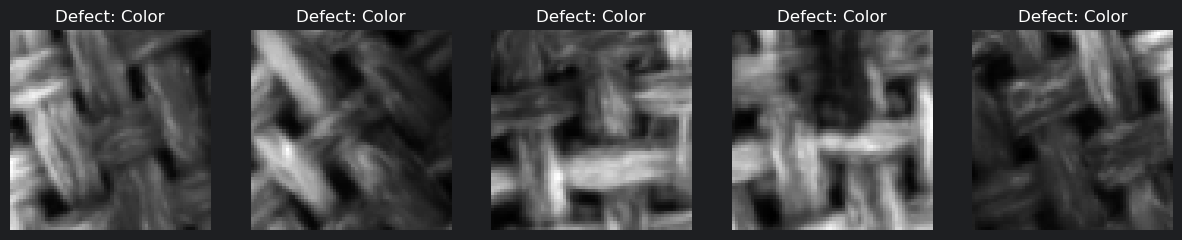

In [11]:
# --- Quick Data Visualization ---
# Show a few color-defect samples for sanity checks.

def visualize_color_defects(dataset, label_map, num_samples=5):
    # Find the integer index for the 'color' class
    if "color" not in label_map:
        print("[INFO] 'color' class is not in current label_map. Skipping visualization.")
        return
    color_idx = label_map["color"]

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]

    found = 0
    for img, label in dataset:
        label_val = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_val == color_idx:
            # Reshape from (1, 64, 64) to (64, 64) for plotting
            axes[found].imshow(img.squeeze(), cmap="gray")
            axes[found].set_title("Defect: Color")
            axes[found].axis("off")
            found += 1
        if found == num_samples:
            break

    if found < num_samples:
        print(f"Only found {found} color samples.")
    plt.show()


# Optional quick demo: safe to run before/after training cells.
train_split_csv = TRAIN_SPLIT_CSV
if train_split_csv.exists():
    demo_label_map = load_or_create_label_map(train_split_csv, persist_json=False)
    demo_train_ds = TextileDataset(train_split_csv, OUT_H5, label_map=demo_label_map)
    visualize_color_defects(demo_train_ds, demo_label_map)
else:
    print("[INFO] train_split.csv not found yet. Run split-generation/training cells first, then rerun this cell.")


In [12]:
# --- Training Utilities ---

class EarlyStopping:
    """Monitors a metric and stops training if it stops improving."""
    def __init__(self, patience=5, verbose=True, mode="min", metric_name="metric", min_delta=0.0):
        if mode not in {"min", "max"}: raise ValueError("mode must be 'min' or 'max'")
        self.patience, self.verbose, self.mode = patience, verbose, mode
        self.metric_name, self.min_delta = metric_name, min_delta
        self.counter, self.early_stop = 0, False
        self.best_score = float("inf") if mode == "min" else -float("inf")
        self.best_model_state = None

    def _is_improvement(self, score):
        """Checks if the current score improves upon the best recorded score."""
        if self.mode == "min": return score < (self.best_score - self.min_delta)
        return score > (self.best_score + self.min_delta)

    def __call__(self, score, model):
        """Updates early stopping status based on the latest validation score."""
        if self._is_improvement(score):
            self.best_score, self.counter = score, 0
            self.best_model_state = copy.deepcopy(model.state_dict())
            if self.verbose: print(f"Validation {self.metric_name} improved. Saving weights.")
        else:
            self.counter += 1
            if self.verbose: print(f"EarlyStopping counter: {self.counter} of {self.patience}")
            if self.counter >= self.patience: self.early_stop = True

def _compute_macro_auprc_safe(y_true, y_prob, num_classes):
    """Compute macro AUPRC only for classes present in y_true."""
    y_true_bin = np.eye(num_classes)[y_true]
    ap_values = []

    for cls_id in range(num_classes):
        y_cls = y_true_bin[:, cls_id]
        # Skip absent classes to avoid sklearn "No positive class" warnings.
        if not np.any(y_cls == 1):
            continue
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    message="No positive class found in y_true, recall is set to one for all thresholds.",
                    category=UserWarning,
                )
                ap = average_precision_score(y_cls, y_prob[:, cls_id])
            ap_values.append(float(ap))
        except Exception:
            continue

    if not ap_values:
        return float("nan")
    return float(np.mean(ap_values))


def _compute_eval_metrics(y_true, y_pred, y_prob, num_classes):
    """Calculates Accuracy, F1-score, and AUPRC."""
    acc = 100.0 * (y_pred == y_true).sum() / max(len(y_true), 1)
    f1 = f1_score(y_true, y_pred, labels=list(range(num_classes)),
                  average=EVAL_CFG["f1_average"], zero_division=EVAL_CFG["zero_division"])
    auprc = _compute_macro_auprc_safe(y_true, y_prob, num_classes)
    return {"accuracy": float(acc), "f1": float(f1), "auprc": float(auprc)}

def _metric_to_str(v, digits=4):
    """Converts a numeric metric value to a formatted string, handling NaNs."""
    return "nan" if np.isnan(v) else f"{v:.{digits}f}"

def run_step(model, loader, criterion, optimizer, device, is_train=True):
    """Executes a single training or validation epoch across the provided loader."""
    model.train() if is_train else model.eval()
    total_loss, all_true, all_pred, all_prob = 0.0, [], [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            all_true.append(labels.cpu().numpy())
            all_pred.append(outputs.argmax(dim=1).cpu().numpy())
            all_prob.append(torch.softmax(outputs, dim=1).detach().cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    if not all_true: return avg_loss, {"accuracy": 0.0, "f1": 0.0, "auprc": float("nan")}

    y_true, y_pred, y_prob = np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_prob)
    return avg_loss, _compute_eval_metrics(y_true, y_pred, y_prob, y_prob.shape[1])

In [13]:
# --- Baseline Pipeline Entry ---
# Use shared TRAIN_CFG settings and the `all_training` split.



In [14]:
# --- Build processed dataset and baseline split files ---
merge_data()
hashes = analyze_duplicates()
create_clean_split(hashes, BASELINE_SPLIT_CFG["defect_classes"], BASELINE_SPLIT_CFG["train_size"],
                   BASELINE_SPLIT_CFG["defect_frac"])


Dataset already merged.
[SAFE] No split leakage.
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=43058
  good: 7200
  cut: 7192
  color: 7192
  hole: 7182
  thread: 7160
  metal_contamination: 7132

[VAL SPLIT] total_i

In [15]:
# --- Build and validate label map for baseline split ---
label_map = load_or_create_label_map(OUT_CSV)
validate_common_splits(label_map, include_test=True)
print("\nlabel_map:", label_map)



label_map: {'good': 0, 'color': 1, 'cut': 2, 'hole': 3, 'thread': 4, 'metal_contamination': 5}


In [16]:
# --- Create datasets and dataloaders ---
train_ds, val_ds, train_loader, val_loader = make_split_datasets_and_loaders(label_map, TRAIN_CFG["batch"])


In [17]:
# --- Initialize baseline CNN training components ---
# --- Dependency Check ---
# torchinfo is optional; skip model summary if unavailable.
if torchinfo is None:
    print("[INFO] torchinfo not installed. Skipping model summary.")

# --- Model Setup ---
model = TextileBaselineCNN(num_classes=len(label_map)).to(device)
print("Baseline CNN Model Summary for Textile Defect Detection:")

if torchinfo is not None:
    dummy_input = torch.randn(TRAIN_CFG["batch"], 1, 64, 64).to(device)
    summary_obj = torchinfo.summary(
        model,
        input_data=dummy_input,
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=0,
    )
    print(summary_obj)

# --- Training Objects ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=OPTIM_CFG["lr"], foreach=OPTIM_CFG["foreach"])
early_stop = EarlyStopping(
    patience=TRAIN_CFG["patience"],
    verbose=True,
    mode=EVAL_CFG["early_stop_mode"],
    metric_name=EVAL_CFG["early_stop_metric"],
)

Baseline CNN Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
TextileBaselineCNN                       [512, 1, 64, 64]          [512, 6]                  --                        --
├─Sequential: 1-1                        [512, 1, 64, 64]          [512, 128, 8, 8]          --                        --
│    └─Conv2d: 2-1                       [512, 1, 64, 64]          [512, 32, 64, 64]         320                       [3, 3]
│    └─BatchNorm2d: 2-2                  [512, 32, 64, 64]         [512, 32, 64, 64]         64                        --
│    └─ReLU: 2-3                         [512, 32, 64, 64]         [512, 32, 64, 64]         --                        --
│    └─MaxPool2d: 2-4                    [512, 32, 64, 64]         [512, 32, 32, 32]         --                        2
│    └─Conv2d: 2-5                       [512, 32, 32, 32]         [512, 64,

In [18]:
# --- Train baseline CNN and save best checkpoint ---
print(f"\nStarting training on: {device}")

# Initialize progress bar for Colab notebook
pbar = tqdm(range(TRAIN_CFG["epochs"]), desc="Baseline CNN")

# Disable verbose output for early stopping as requested
early_stop.verbose = False

history = []

for epoch in pbar:
    # Run training and validation steps
    t_loss, t_metrics = run_step(model, train_loader, criterion, optimizer, device, is_train=True)
    v_loss, v_metrics = run_step(model, val_loader, criterion, optimizer, device, is_train=False)

    # Store history for final reporting
    history.append({
        "epoch": epoch + 1,
        "f1": v_metrics["f1"],
        "auprc": v_metrics["auprc"],
        "accuracy": v_metrics["accuracy"]
    })

    # Update progress bar with metrics
    pbar.set_postfix({
        "v_f1": _metric_to_str(v_metrics["f1"]),
        "v_acc": _metric_to_str(v_metrics["accuracy"], digits=2),
        "v_loss": f"{v_loss:.4f}"
    })

    # Early stopping logic
    early_stop(v_metrics[EVAL_CFG["early_stop_metric"]], model)
    if early_stop.early_stop:
        pbar.write(f"Early stopping triggered at epoch {epoch + 1}")
        model.load_state_dict(early_stop.best_model_state)
        break

# Save final model
torch.save(model.state_dict(), OUTPUT_DIR / "best_textile_baseline.pth")

# Find best performance stats
best_record = max(history, key=lambda x: x["f1"])

print("\n" + "="*40)
print("TRAINING COMPLETE")
print(f"Best Performance at Epoch: {best_record['epoch']}")
print(f"F1 Score: {best_record['f1']:.4f}")
print(f"AUPRC:    {best_record['auprc']:.4f}")
print(f"Accuracy: {best_record['accuracy']:.2f}%")
print(f"Final model saved to: {OUTPUT_DIR / 'best_textile_baseline.pth'}")
print("="*40)


Starting training on: cpu


Baseline CNN:   0%|          | 0/30 [00:00<?, ?it/s]

Early stopping triggered at epoch 15

TRAINING COMPLETE
Best Performance at Epoch: 10
F1 Score: 0.8430
AUPRC:    0.9100
Accuracy: 84.39%
Final model saved to: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\best_textile_baseline.pth


In [19]:
# --- ResNet Model Definition ---
# ResNet-18 adapted for 64x64 grayscale textile images.
class TextileResNet(nn.Module):
    def __init__(self, num_classes: int):
        super(TextileResNet, self).__init__()

        # Load pre-trained ResNet-18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Adapt stem for 1x64x64 grayscale inputs
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

        # Adapt output head for specific num_classes
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

In [20]:
# --- Preview ResNet Model ---
# Instantiate a preview ResNet (all-training scenario class count)
label_map_all = load_or_create_label_map(OUT_CSV)
model_preview = TextileResNet(len(label_map_all)).to(device)

print("ResNet-18 Model Summary for Textile Defect Detection:")
if torchinfo is not None:
    summary_obj = torchinfo.summary(
        model_preview,
        input_size=(TRAIN_CFG["batch"], 1, 64, 64),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=0,
    )
    print(summary_obj)
else:
    print("[INFO] torchinfo not installed. Skipping model summary.")


ResNet-18 Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
TextileResNet                                 [512, 1, 64, 64]          [512, 6]                  --                        --
├─ResNet: 1-1                                 [512, 1, 64, 64]          [512, 6]                  --                        --
│    └─Conv2d: 2-1                            [512, 1, 64, 64]          [512, 64, 64, 64]         576                       [3, 3]
│    └─BatchNorm2d: 2-2                       [512, 64, 64, 64]         [512, 64, 64, 64]         128                       --
│    └─ReLU: 2-3                              [512, 64, 64, 64]         [512, 64, 64, 64]         --                        --
│    └─MaxPool2d: 2-4                         [512, 64, 64, 64]         [512, 64, 32, 32]         --                        3
│    └─Sequential: 2-5                      

In [21]:
# --- Prepare Scenario Data and Loaders ---
# Build split files, label maps, datasets, and dataloaders for one scenario.
def prepare_resnet_split_and_loaders(split_name: str, split_cfg: SplitScenario, train_cfg: Dict[str, int]):
    create_clean_split(
        hashes,
        split_cfg["defect_classes"],
        split_cfg["train_size"],
        split_cfg["defect_frac"],
    )

    split_label_map = load_or_create_label_map(TRAIN_SPLIT_CSV)
    validate_common_splits(split_label_map, include_test=False)

    split_train_ds, split_val_ds, split_train_loader, split_val_loader = make_split_datasets_and_loaders(
        split_label_map, train_cfg["batch"]
    )
    split_test_ds, split_test_loader, split_test_csv = make_filtered_test_dataset_and_loader(
        split_label_map,
        train_cfg["batch"],
        split_tag=f"resnet_{split_name}",
    )

    return (
        split_label_map,
        split_train_ds,
        split_val_ds,
        split_test_ds,
        split_train_loader,
        split_val_loader,
        split_test_loader,
        split_test_csv,
    )


In [22]:
# --- ResNet Training Across Split Scenarios ---
resnet_models, resnet_histories, resnet_label_maps, resnet_loaders = {}, {}, {}, {}
resnet_summary = []

for scenario_name, split_cfg in SPLIT_SCENARIOS.items():
    print(f"\n=== ResNet Scenario: {scenario_name} ===")

    # Setup data for current scenario
    res = prepare_resnet_split_and_loaders(scenario_name, split_cfg, TRAIN_CFG)
    split_label_map, split_train_ds, split_val_ds, split_test_ds, split_train_loader, split_val_loader, split_test_loader, split_test_csv = res

    # Initialize model and components
    model_curr = TextileResNet(num_classes=len(split_label_map)).to(device)
    optimizer_curr = optim.Adam(model_curr.parameters(), lr=OPTIM_CFG["lr"])
    criterion_curr = nn.CrossEntropyLoss()
    stopper_curr = EarlyStopping(patience=TRAIN_CFG["patience"], verbose=False, mode="max", metric_name="f1")

    history_curr = []
    pbar = tqdm(range(TRAIN_CFG["epochs"]), desc=f"ResNet {scenario_name}")

    for epoch in pbar:
        t_loss, t_met = run_step(model_curr, split_train_loader, criterion_curr, optimizer_curr, device, True)
        v_loss, v_met = run_step(model_curr, split_val_loader, criterion_curr, optimizer_curr, device, False)

        for split, loss, met in [("Train", t_loss, t_met), ("Val", v_loss, v_met)]:
            history_curr.append({"Epoch": epoch+1, "Split": split, "Loss": loss, "Accuracy": met["accuracy"], "F1": met["f1"], "AUPRC": met["auprc"]})

        pbar.set_postfix({"val_f1": _metric_to_str(v_met["f1"]), "val_acc": _metric_to_str(v_met["accuracy"], 2)})
        stopper_curr(v_met["f1"], model_curr)
        if stopper_curr.early_stop: break

    # Save and summarize
    if stopper_curr.best_model_state: model_curr.load_state_dict(stopper_curr.best_model_state)
    val_best = max([h for h in history_curr if h["Split"] == "Val"], key=lambda x: x["F1"])

    resnet_summary.append({"Model": "ResNet-18", "Scenario": scenario_name, "Best Epoch": val_best["Epoch"], "F1": val_best["F1"], "AUPRC": val_best["AUPRC"], "Accuracy": val_best["Accuracy"]})

    # Store results and loaders for evaluation/visualization
    resnet_models[scenario_name] = model_curr
    resnet_histories[scenario_name] = history_curr
    resnet_label_maps[scenario_name] = split_label_map
    resnet_loaders[scenario_name] = {
        "train_ds": split_train_ds,
        "test_loader": split_test_loader,
        "test_ds": split_test_ds,
        "test_csv": split_test_csv
    }

# Backward-compatible aliases for plotting/IG cells.
results_resnet = resnet_histories.get(BASELINE_SCENARIO, [])
if BASELINE_SCENARIO in resnet_models:
    model_resnet = resnet_models[BASELINE_SCENARIO]
    train_label_map = resnet_label_maps[BASELINE_SCENARIO]
    train_ds = resnet_loaders[BASELINE_SCENARIO]["train_ds"]


=== ResNet Scenario: all_training ===
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=43058
  good: 7200
  cut: 7192
  color: 7192
  hole: 7182
  thread: 7160
  metal_contamination: 7132

[VAL SPLIT] total_images=4785

ResNet all_training:   0%|          | 0/30 [00:00<?, ?it/s]


=== ResNet Scenario: fifty_fifty ===
Duplicates removed (within split): train=157, test=234, total=391
[WARN] class=good: requested 10000, available 8000, using 8000
Datasets finalized: Train(16200), Val(1800), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=16200
  good: 7200
  metal_contamination: 1800
  thread: 1800
  color

ResNet fifty_fifty:   0%|          | 0/30 [00:00<?, ?it/s]


=== ResNet Scenario: exclude_two_classes ===
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(28765), Val(3197), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=31962
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=28765
  good: 7200
  cut: 7192
  color: 7191
  hole: 7182

[VAL SPLIT] total_images=3197
  good: 800
  color: 800
  cut: 799
  hole: 798

[TEST SPLIT] total_images=477

ResNet exclude_two_classes:   0%|          | 0/30 [00:00<?, ?it/s]


=== ResNet Scenario: imbalanced ===
Duplicates removed (within split): train=157, test=234, total=391
[WARN] class=good: requested 18000, available 8000, using 8000
Datasets finalized: Train(9000), Val(1000), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=9000
  good: 7200
  thread: 360
  color: 360
  hole: 360
  cut: 360
  m

ResNet imbalanced:   0%|          | 0/30 [00:00<?, ?it/s]

In [23]:
# --- Final Test Evaluation (Baseline CNN + ResNet) ---
# This cell provides a consolidated view of final model performance on unseen test data.
test_eval_rows = []

if {"model", "label_map", "device"}.issubset(globals()):
    baseline_test_ds, baseline_test_loader, baseline_test_csv = make_filtered_test_dataset_and_loader(
        label_map,
        TRAIN_CFG["batch"],
        split_tag="baseline_cnn",
    )
    baseline_n_samples = len(baseline_test_ds) if isinstance(baseline_test_ds, Sized) else 0
    baseline_test_loss, baseline_test_metrics = evaluate_loader(model, baseline_test_loader, device)
    test_eval_rows.append(
        {
            "model": "baseline_cnn",
            "scenario": BASELINE_SCENARIO,
            "n_samples": baseline_n_samples,
            "loss": baseline_test_loss,
            "accuracy": baseline_test_metrics["accuracy"],
            "f1": baseline_test_metrics["f1"],
            "auprc": baseline_test_metrics["auprc"],
            "test_csv": str(baseline_test_csv),
        }
    )
else:
    print("[WARN] Baseline CNN globals not ready. Skipping baseline test evaluation.")

if {"resnet_models", "resnet_label_maps", "resnet_loaders", "device"}.issubset(globals()):
    for scenario_name in SPLIT_SCENARIOS.keys():
        if scenario_name not in resnet_models:
            continue

        split_test_loader = resnet_loaders[scenario_name]["test_loader"]
        split_test_ds = resnet_loaders[scenario_name]["test_ds"]
        split_test_csv = resnet_loaders[scenario_name]["test_csv"]
        split_n_samples = len(split_test_ds) if isinstance(split_test_ds, Sized) else 0
        split_test_loss, split_test_metrics = evaluate_loader(
            resnet_models[scenario_name],
            split_test_loader,
            device,
        )
        test_eval_rows.append(
            {
                "model": "resnet18",
                "scenario": scenario_name,
                "n_samples": split_n_samples,
                "loss": split_test_loss,
                "accuracy": split_test_metrics["accuracy"],
                "f1": split_test_metrics["f1"],
                "auprc": split_test_metrics["auprc"],
                "test_csv": str(split_test_csv),
            }
        )
else:
    print("[WARN] ResNet globals not ready. Skipping ResNet test evaluation.")

if test_eval_rows:
    test_eval_results = pd.DataFrame(test_eval_rows)
    print("\n=== Final Test-set Performance Summary ===")
    summary_cols = ["model", "scenario", "n_samples", "accuracy", "f1", "auprc", "loss"]
    if "display" in globals():
        display(test_eval_results[summary_cols])
    else:
        print(test_eval_results[summary_cols].to_string(index=False))
else:
    print("[WARN] No test evaluation results produced.")


=== Final Test-set Performance Summary ===
       model            scenario  n_samples  accuracy       f1    auprc     loss
baseline_cnn        all_training      47766 70.675794 0.712728 0.742860 1.024115
    resnet18        all_training      47766 72.526483 0.712898 0.743097 2.524976
    resnet18         fifty_fifty      47766 71.402253 0.700838 0.737710 2.376072
    resnet18 exclude_two_classes      47766 47.889712 0.399441 0.493771 5.569725
    resnet18          imbalanced      47766 67.326132 0.665596 0.727062 1.834211


Saved history plot (.jpg): C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_all_training_metrics.jpg


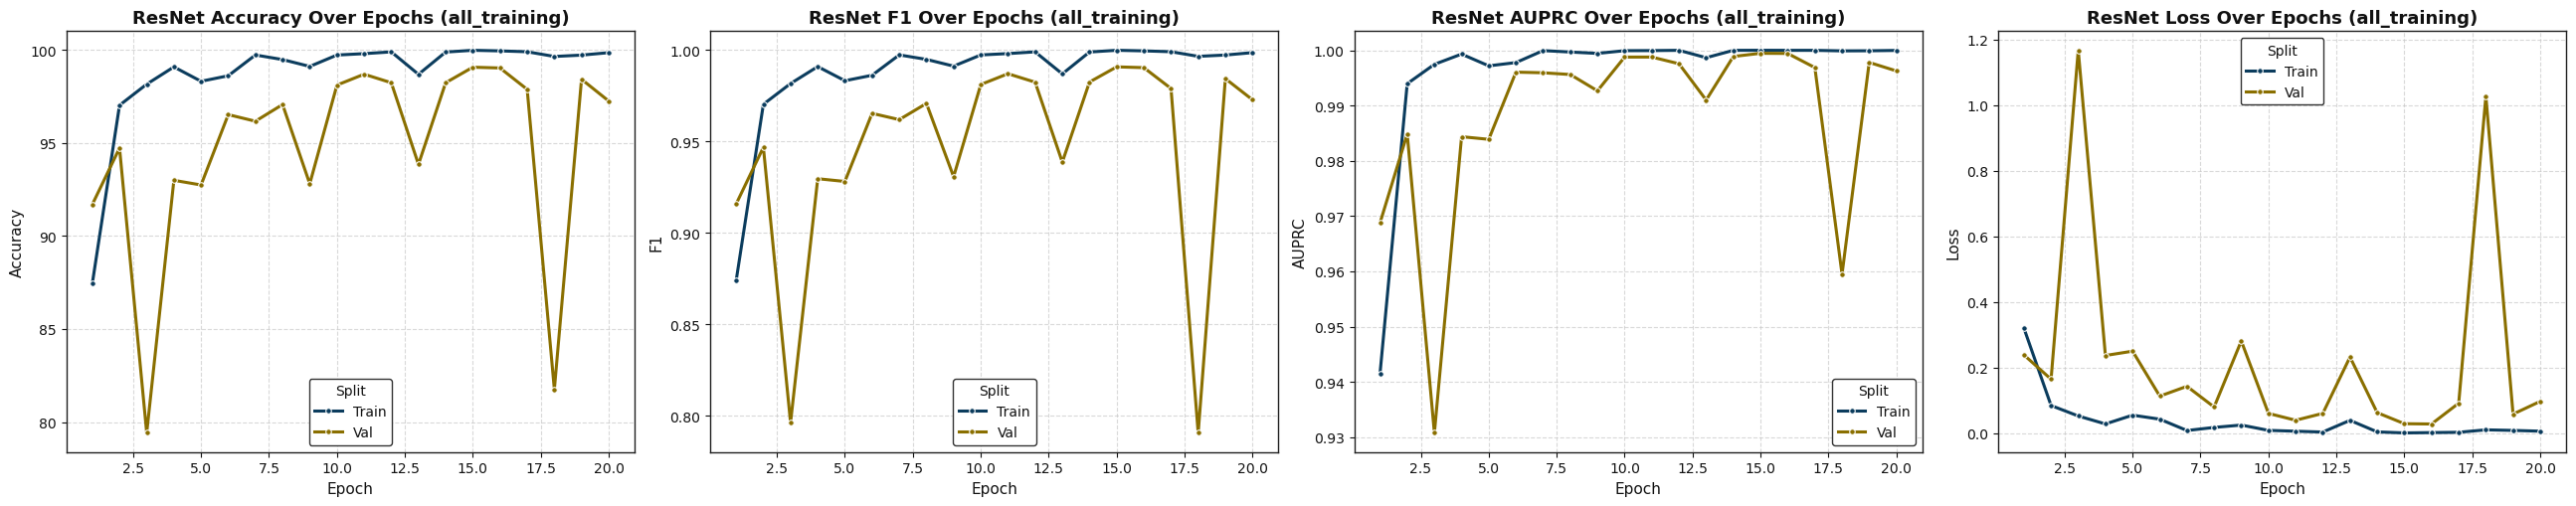


--- Generating Confusion Matrices on Test Sets ---

[INFO] Drawing Confusion Matrix for CNN Baseline...
Saved confusion matrix: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\cnn_baseline_confusion.png


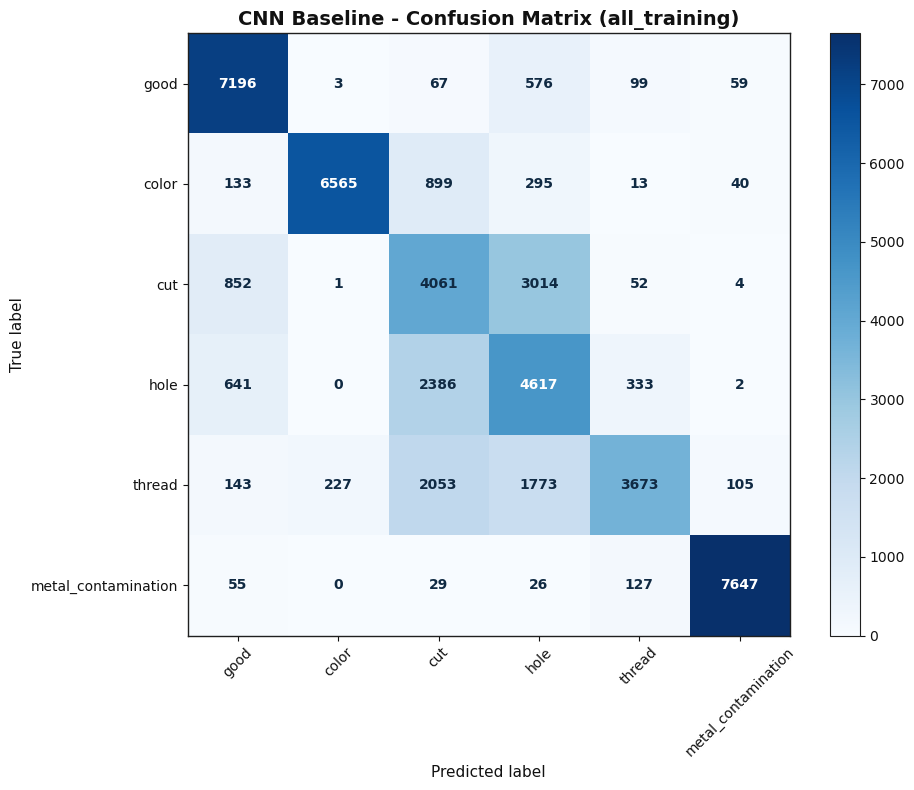


[INFO] Drawing Confusion Matrix for ResNet-18 (all_training)...
Saved confusion matrix: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_all_training_confusion.png


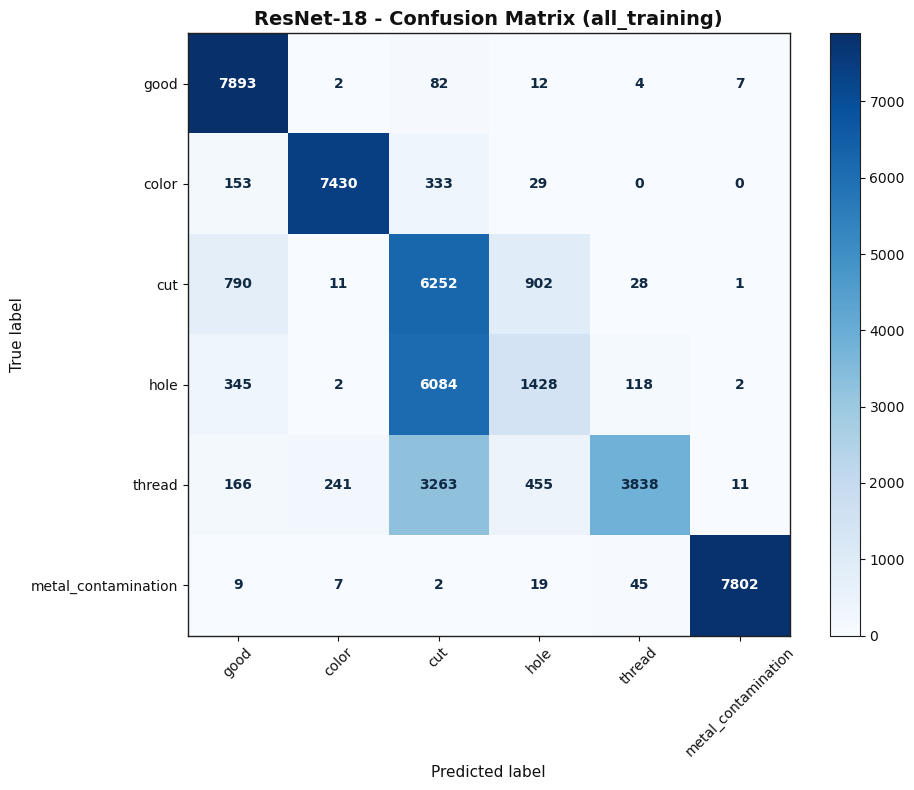


[INFO] Drawing Confusion Matrix for ResNet-18 (fifty_fifty)...
Saved confusion matrix: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_fifty_fifty_confusion.png


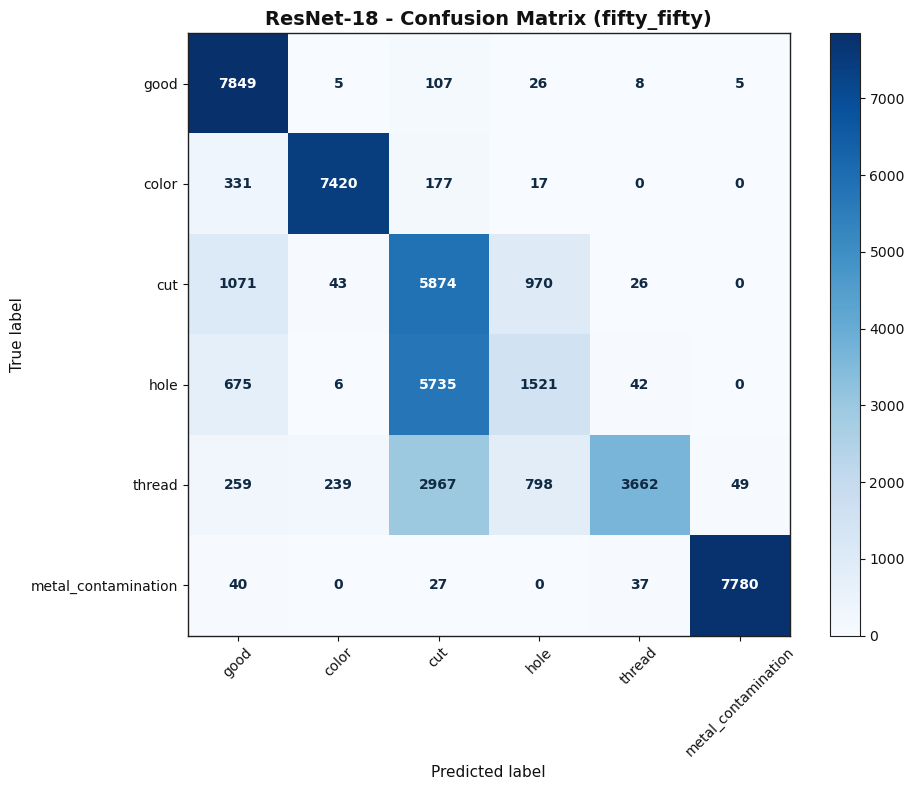


[INFO] Drawing Confusion Matrix for ResNet-18 (exclude_two_classes)...
Saved confusion matrix: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_exclude_two_classes_confusion.png


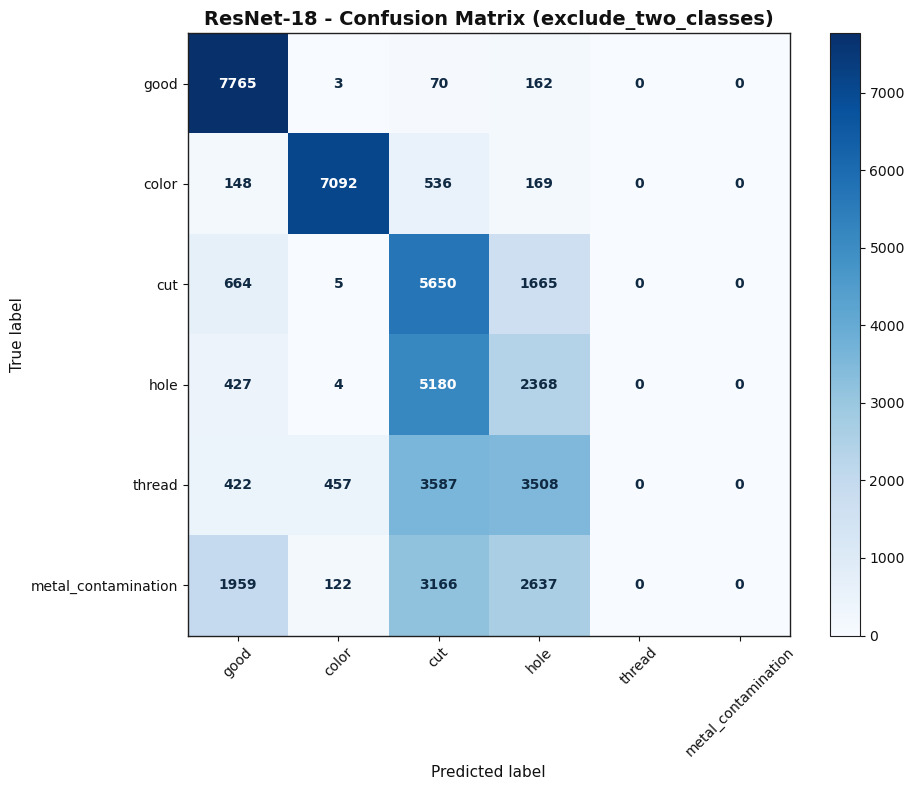


[INFO] Drawing Confusion Matrix for ResNet-18 (imbalanced)...
Saved confusion matrix: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_imbalanced_confusion.png


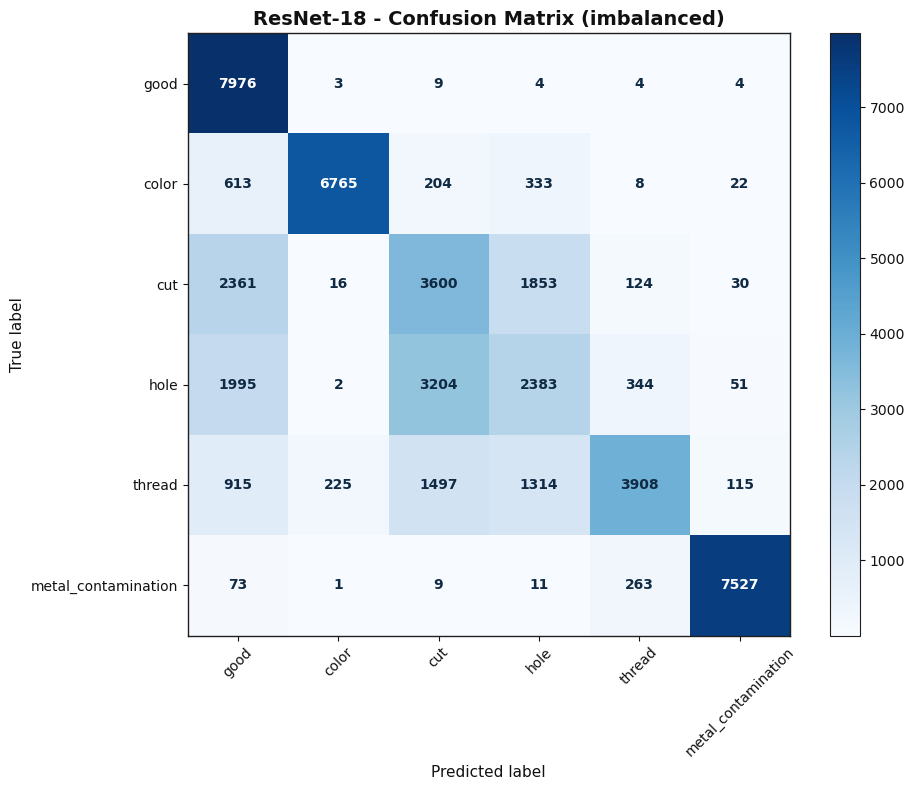

In [24]:
# --- Result Visualization and Reports ---
def plot_history(results_list, save_path=None, dpi=280):
    history_df = pd.DataFrame(results_list)
    metrics = [m for m in ["Accuracy", "F1", "AUPRC", "Loss"] if m in history_df.columns]
    if not metrics:
        print("[INFO] No plottable metrics found in history.")
        return

    line_colors = {"Train": "#0b3c5d", "Val": "#8a6f00"}

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "axes.grid": False,
        "xtick.color": "#111111",
        "ytick.color": "#111111",
        "grid.color": "#c6c6c6",
        "grid.alpha": 0.65,
        "grid.linestyle": "--",
    }):
        fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 5.2))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        if len(metrics) == 1:
            axes = [axes]

        for i, metric in enumerate(metrics):
            ax = axes[i]
            ax.set_facecolor("#ffffff")
            ax.patch.set_alpha(1.0)
            if sns is not None:
                sns.lineplot(
                    data=history_df,
                    x="Epoch",
                    y=metric,
                    hue="Split",
                    palette=line_colors,
                    ax=ax,
                    linewidth=2.2,
                    marker="o",
                    markersize=4,
                )
            else:
                for split in history_df["Split"].unique():
                    split_df = history_df[history_df["Split"] == split]
                    color = line_colors.get(split, "#333333")
                    ax.plot(split_df["Epoch"], split_df[metric], label=split, linewidth=2.2, marker="o", markersize=4,
                            color=color)
                ax.legend()

            ax.set_title(f"ResNet {metric} Over Epochs (all_training)", fontsize=13, fontweight="bold", color="#111111")
            ax.set_xlabel("Epoch", fontsize=11, color="#111111")
            ax.set_ylabel(metric, fontsize=11, color="#111111")
            ax.tick_params(axis="both", labelsize=10, colors="#111111")
            ax.grid(True, linewidth=0.8)
            for spine in ax.spines.values():
                spine.set_color("#1f1f1f")
                spine.set_linewidth(1.0)
            legend = ax.get_legend()
            if legend is not None:
                legend.set_title("Split")
                legend.get_title().set_color("#111111")
                for text in legend.get_texts():
                    text.set_color("#111111")
                frame = legend.get_frame()
                frame.set_facecolor("#ffffff")
                frame.set_edgecolor("#333333")
                frame.set_alpha(1.0)

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            if save_path.suffix.lower() not in {".jpg", ".jpeg"}:
                save_path = save_path.with_suffix(".jpg")
            save_path.parent.mkdir(parents=True, exist_ok=True)
            if save_path.exists():
                save_path.unlink()
            fig.savefig(
                save_path,
                dpi=dpi,
                format="jpeg",
                facecolor="white",
                edgecolor="white",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved history plot (.jpg): {save_path}")
        plt.show()
        plt.close(fig)


# --- The Confusion Matrix (Evaluating on Test Sets) ---
def show_confusion_matrix(model, loader, label_map, device, title="Confusion Matrix", save_path=None, dpi=220):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    class_names = list(label_map.keys())

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "xtick.color": "#111111",
        "ytick.color": "#111111",
    }):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        ax.set_facecolor("#ffffff")
        ax.patch.set_alpha(1.0)
        disp.plot(
            ax=ax,
            cmap="Blues",
            xticks_rotation=45,
            colorbar=True,
            values_format="d",
            im_kw={"interpolation": "nearest"},
        )
        ax.grid(False)
        ax.set_title(title, fontsize=14, fontweight="bold", color="#111111")
        ax.set_xlabel("Predicted label", fontsize=11, color="#111111")
        ax.set_ylabel("True label", fontsize=11, color="#111111")
        ax.tick_params(axis="both", labelsize=10, colors="#111111")
        for spine in ax.spines.values():
            spine.set_color("#1f1f1f")
            spine.set_linewidth(1.0)

        if disp.im_ is not None and disp.im_.colorbar is not None:
            cbar = disp.im_.colorbar
            cbar.ax.tick_params(colors="#111111")
            cbar.outline.set_edgecolor("#1f1f1f")

        if disp.text_ is not None:
            threshold = cm.max() * 0.60 if cm.size else 0
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    txt = disp.text_[i, j]
                    if txt is None:
                        continue
                    txt.set_fontsize(10)
                    txt.set_fontweight("semibold")
                    txt.set_color("white" if cm[i, j] > threshold else "#102a43")

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            if save_path.exists():
                save_path.unlink()
            fmt = "jpeg" if save_path.suffix.lower() in {".jpg", ".jpeg"} else None
            fig.savefig(
                save_path,
                dpi=dpi,
                format=fmt,
                facecolor="#ffffff",
                edgecolor="#ffffff",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved confusion matrix: {save_path}")
        plt.show()
        plt.close(fig)


# Auto-run visualization for Plot History
if {"resnet_histories"}.issubset(globals()) and BASELINE_SCENARIO in resnet_histories:
    results_resnet = resnet_histories[BASELINE_SCENARIO]
    plot_history(results_resnet, save_path=OUTPUT_DIR / "resnet_all_training_metrics.jpg")

print("\n--- Generating Confusion Matrices on Test Sets ---")

# 1) CNN Baseline Confusion Matrix
if {"model", "label_map", "device"}.issubset(globals()):
    print("\n[INFO] Drawing Confusion Matrix for CNN Baseline...")
    # Reuse test loader if already built in test-evaluation cell.
    bl_test_loader = globals().get("baseline_test_loader")
    if bl_test_loader is None:
        _, bl_test_loader, _ = make_filtered_test_dataset_and_loader(
            label_map,
            TRAIN_CFG.get("batch", 512),
            split_tag="baseline_cnn"
        )
    if bl_test_loader is not None:
        show_confusion_matrix(
            model,
            bl_test_loader,
            label_map,
            device,
            title=f"CNN Baseline - Confusion Matrix ({BASELINE_SCENARIO})",
            save_path=OUTPUT_DIR / "cnn_baseline_confusion.png",
        )

# 2) ResNet Scenarios Confusion Matrices
if {"resnet_models", "resnet_loaders", "resnet_label_maps", "device"}.issubset(globals()):
    for scenario_name, res_model in resnet_models.items():
        print(f"\n[INFO] Drawing Confusion Matrix for ResNet-18 ({scenario_name})...")
        loader = resnet_loaders[scenario_name]["test_loader"]
        l_map = resnet_label_maps[scenario_name]
        show_confusion_matrix(
            res_model,
            loader,
            l_map,
            device,
            title=f"ResNet-18 - Confusion Matrix ({scenario_name})",
            save_path=OUTPUT_DIR / f"resnet_{scenario_name}_confusion.png",
        )
else:
    print("[INFO] ResNet results not ready. Run the ResNet training cell first.")

In [27]:
# --- Integrated Gradients Utilities ---
# Explain model decisions for all textile classes with trained vs random ResNet comparison.
IG_BASELINE_MODE = "zeros"  # zeros baseline (blank reference tensor)
IG_RETURN_CONVERGENCE_DELTA = True
IG_VIZ_SIGN = "all"
IG_N_STEPS = 50
PENGJU_RESNET_IG_OUTPUT_DIR = Path(r"C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch")
NON_DEFECT_CLASS_NAMES = {
    str(FULL_CLASSES[0]).strip().lower()
} if "FULL_CLASSES" in globals() and len(FULL_CLASSES) > 0 else {"good"}


def _to_hwc(arr: np.ndarray) -> np.ndarray:
    """Normalize image-like arrays to HWC for visualization.

    Accepts: [N,C,H,W], [C,H,W], [H,W,C], [H,W].
    Returns: [H,W,C].
    """
    if arr.ndim == 4:
        if arr.shape[0] != 1:
            raise ValueError(f"Expected batch size 1 for visualization, got shape={arr.shape}")
        arr = arr[0]

    if arr.ndim == 3:
        # If likely CHW, transpose to HWC.
        if arr.shape[0] <= 4 and arr.shape[1] > 4 and arr.shape[2] > 4:
            arr = np.transpose(arr, (1, 2, 0))
        # Else assume already HWC.
    elif arr.ndim == 2:
        arr = arr[..., np.newaxis]
    else:
        raise ValueError(f"Unsupported array shape for visualization: {arr.shape}")

    return arr


def _ig_baseline(input_tensor):
    if IG_BASELINE_MODE == "zeros":
        return torch.zeros_like(input_tensor).to(input_tensor.device)
    raise ValueError(f"Unsupported IG_BASELINE_MODE: {IG_BASELINE_MODE}")


def _resolve_target_class(model, input_tensor, target_class=None):
    if target_class is not None:
        return int(target_class)
    with torch.no_grad():
        output = model(input_tensor)
    return int(torch.argmax(output, dim=1).item())


def apply_integrated_gradients(model, input_tensor, target_class=None):
    """Compute IG attribution for one input image tensor.

    Returns:
      - attributions in HWC numpy format
      - input image in HWC numpy format
      - resolved target class id
    """
    if IntegratedGradients is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    model.eval()
    ig_input = input_tensor.detach().clone().to(device).requires_grad_(True)
    ig = IntegratedGradients(model)
    baseline = _ig_baseline(ig_input)
    target_id = _resolve_target_class(model, ig_input, target_class)

    if IG_RETURN_CONVERGENCE_DELTA:
        attributions, _ = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            n_steps=IG_N_STEPS,
            return_convergence_delta=True,
        )
    else:
        attributions = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            n_steps=IG_N_STEPS,
            return_convergence_delta=False,
        )

    attributions = _to_hwc(attributions.detach().cpu().numpy())
    img_plot = _to_hwc(ig_input.detach().cpu().numpy())
    return attributions, img_plot, target_id


def _displayable_img(img_plot: np.ndarray):
    if img_plot.ndim == 3 and img_plot.shape[-1] == 1:
        return img_plot[..., 0], "gray"
    if img_plot.ndim == 2:
        return img_plot, "gray"
    return img_plot, None


def _displayable_attr(attributions: np.ndarray) -> np.ndarray:
    attr = attributions[..., 0] if attributions.ndim == 3 and attributions.shape[-1] == 1 else attributions
    return np.asarray(attr, dtype=np.float32)


def _normalize_for_overlay(img_plot: np.ndarray) -> np.ndarray:
    img, _ = _displayable_img(img_plot)
    img = np.asarray(img, dtype=np.float32)
    img_min, img_max = float(np.min(img)), float(np.max(img))
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return img


def _ig_abs_vmax(*attribution_arrays) -> float:
    vmax = 0.0
    for attributions in attribution_arrays:
        attr = _displayable_attr(attributions)
        if attr.size:
            vmax = max(vmax, float(np.max(np.abs(attr))))
    return vmax if vmax > 0 else 1.0


def _draw_ig_overlay(ax, attributions, img_plot, title, vmax):
    attr = _displayable_attr(attributions)
    img = _normalize_for_overlay(img_plot)

    ax.imshow(img, cmap="gray", interpolation="nearest")
    overlay = ax.imshow(attr, cmap="RdYlGn", vmin=-vmax, vmax=vmax, alpha=0.62, interpolation="nearest")
    ax.set_title(title, color="#111111", fontsize=11)
    ax.axis("off")
    ax.set_aspect("equal")
    if hasattr(ax, "set_box_aspect"):
        ax.set_box_aspect(1)
    return overlay


def _predict_class(model, input_tensor):
    model.eval()
    with torch.no_grad():
        output = model(input_tensor.to(device))
    return int(torch.argmax(output, dim=1).item())


def _make_random_resnet(num_classes: int):
    """Create an untrained ResNet-18 with random weights only.

    weights=None is intentional here. This must not use ImageNet pre-training.
    """
    random_model = models.resnet18(weights=None)
    random_model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    random_model.fc = nn.Linear(random_model.fc.in_features, num_classes)
    return random_model.to(device)


def _check_trained_and_random_models(trained_model, random_model):
    if trained_model is random_model:
        raise RuntimeError("Trained and random IG models refer to the same model object.")
    trained_param = next(trained_model.parameters()).detach().flatten()[:64].cpu()
    random_param = next(random_model.parameters()).detach().flatten()[:64].cpu()
    if trained_param.shape == random_param.shape and torch.equal(trained_param, random_param):
        print("[WARN] First trained/random parameter values are identical. Check model initialization.")
    print("[INFO] IG models checked: left panel uses trained ResNet; middle panel uses weights=None random ResNet.")


def plot_resnet_ig_comparison(
    trained_attributions,
    random_attributions,
    img_plot,
    trained_predicted_class,
    random_predicted_class,
    actual_class,
    target_class,
    label_map,
    sample_idx=None,
    save_path=None,
):
    idx_to_class = {v: k for k, v in label_map.items()}
    trained_pred_name = idx_to_class.get(int(trained_predicted_class), str(trained_predicted_class))
    random_pred_name = idx_to_class.get(int(random_predicted_class), str(random_predicted_class))
    actual_name = idx_to_class.get(int(actual_class), str(actual_class))
    target_name = idx_to_class.get(int(target_class), str(target_class))
    sample_text = f"test idx={sample_idx}" if sample_idx is not None else "test sample"
    vmax = _ig_abs_vmax(trained_attributions, random_attributions)

    fig = plt.figure(figsize=(12.5, 5.2), constrained_layout=True)
    fig.patch.set_facecolor("#ffffff")
    gs = fig.add_gridspec(2, 3, height_ratios=[20, 1], hspace=0.08, wspace=0.18)
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[1, 0:2])

    overlay = _draw_ig_overlay(axes[0], trained_attributions, img_plot, "Trained ResNet IG", vmax)
    _draw_ig_overlay(axes[1], random_attributions, img_plot, "Random-Weight ResNet IG", vmax)
    disp_img, cmap = _displayable_img(img_plot)
    axes[2].imshow(disp_img, cmap=cmap, interpolation="nearest")
    axes[2].set_title("Original Image", color="#111111", fontsize=11)
    axes[2].axis("off")
    axes[2].set_aspect("equal")
    if hasattr(axes[2], "set_box_aspect"):
        axes[2].set_box_aspect(1)

    cbar = fig.colorbar(overlay, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(colors="#111111", labelsize=8)
    cbar.set_label(
        "IG attribution intensity: red = negative evidence, white/yellow = near zero, green = positive evidence",
        color="#111111",
        fontsize=9,
        labelpad=4,
    )

    fig.suptitle(
        (
            f"ResNet IG Comparison | {sample_text} | Actual: {actual_name} | "
            f"Target: {target_name} | Trained pred: {trained_pred_name} | Random pred: {random_pred_name}"
        ),
        fontsize=11,
        color="#111111",
    )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            dpi=220,
            format="png",
            facecolor="#ffffff",
            edgecolor="#ffffff",
            transparent=False,
            bbox_inches="tight",
        )
        print(f"Saved ResNet IG comparison: {save_path}")
    plt.show()
    plt.close(fig)


def _defect_classes(label_map: Dict[str, int]):
    classes = []
    for class_name, class_id in label_map.items():
        if str(class_name).strip().lower() not in NON_DEFECT_CLASS_NAMES:
            classes.append((str(class_name), int(class_id)))
    if not classes:
        classes = [(str(class_name), int(class_id)) for class_name, class_id in label_map.items()]
    return classes


def _ig_analysis_classes(label_map: Dict[str, int]):
    ordered_names = [str(name) for name in globals().get("FULL_CLASSES", list(label_map.keys()))]
    classes = [(name, int(label_map[name])) for name in ordered_names if name in label_map]
    if classes:
        return classes
    return [(str(class_name), int(class_id)) for class_name, class_id in label_map.items()]


def _safe_token(text: str) -> str:
    token = "".join(ch if (ch.isalnum() or ch in "-_") else "_" for ch in str(text))
    while "__" in token:
        token = token.replace("__", "_")
    return token.strip("_") or "na"


def _first_sample_index_per_class(dataset, target_class_ids):
    sample_indices = {}

    # Fast path: use dataframe labels directly to avoid loading many images from H5.
    if hasattr(dataset, "df") and hasattr(dataset, "label_map"):
        labels = dataset.df["indication_type"].astype(str).str.strip().tolist()
        for idx, class_name in enumerate(labels):
            label_id = int(dataset.label_map[class_name])
            if label_id in target_class_ids and label_id not in sample_indices:
                sample_indices[label_id] = idx
                if len(sample_indices) == len(target_class_ids):
                    break
        return sample_indices

    # Fallback path
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_id = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_id in target_class_ids and label_id not in sample_indices:
            sample_indices[label_id] = idx
            if len(sample_indices) == len(target_class_ids):
                break
    return sample_indices


def run_ig_demo_per_defect_class(model, dataset, label_map, device, output_dir: Path = OUTPUT_DIR):
    """Backward-compatible wrapper for the original IG demo name."""
    return run_resnet_ig_pengju_comparison(model, dataset, label_map, device, output_dir=PENGJU_RESNET_IG_OUTPUT_DIR)


def run_resnet_ig_pengju_comparison(model, dataset, label_map, device, output_dir: Path = PENGJU_RESNET_IG_OUTPUT_DIR):
    """Save one test-set sample per class as ResNet IG comparison images.

    Each saved PNG contains three subimages: trained all-training ResNet IG,
    random-weight ResNet IG, and the original textile image.
    """
    if plt is None:
        raise ImportError("matplotlib is required for IG visualization")
    if IntegratedGradients is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    analysis_classes = _ig_analysis_classes(label_map)
    target_class_ids = {class_id for _, class_id in analysis_classes}
    sample_indices = _first_sample_index_per_class(dataset, target_class_ids)

    if not sample_indices:
        print("[WARN] No class samples found for IG visualization.")
        return []

    random_model = _make_random_resnet(num_classes=len(label_map))
    _check_trained_and_random_models(model, random_model)
    saved_files = []

    for class_name, class_id in analysis_classes:
        if class_id not in sample_indices:
            print(f"[WARN] No sample found for class '{class_name}' (id={class_id}) in test set.")
            continue

        ds_idx = sample_indices[class_id]
        sample_img, true_label = dataset[ds_idx]
        input_tensor = sample_img.unsqueeze(0).to(device)
        true_cls = int(true_label.item()) if torch.is_tensor(true_label) else int(true_label)

        trained_attrs, img_plot, target_cls = apply_integrated_gradients(model, input_tensor, target_class=true_cls)
        random_attrs, _, _ = apply_integrated_gradients(random_model, input_tensor, target_class=true_cls)
        trained_pred_cls = _predict_class(model, input_tensor)
        random_pred_cls = _predict_class(random_model, input_tensor)

        save_file = Path(output_dir) / f"resnet_ig_comparison_test_{_safe_token(class_name)}_idx_{ds_idx}.png"
        plot_resnet_ig_comparison(
            trained_attrs,
            random_attrs,
            img_plot,
            trained_pred_cls,
            random_pred_cls,
            true_cls,
            target_cls,
            label_map,
            sample_idx=ds_idx,
            save_path=save_file,
        )
        saved_files.append(save_file)

    return saved_files


[INFO] IG models checked: left panel uses trained ResNet; middle panel uses weights=None random ResNet.
Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_good_idx_0.png


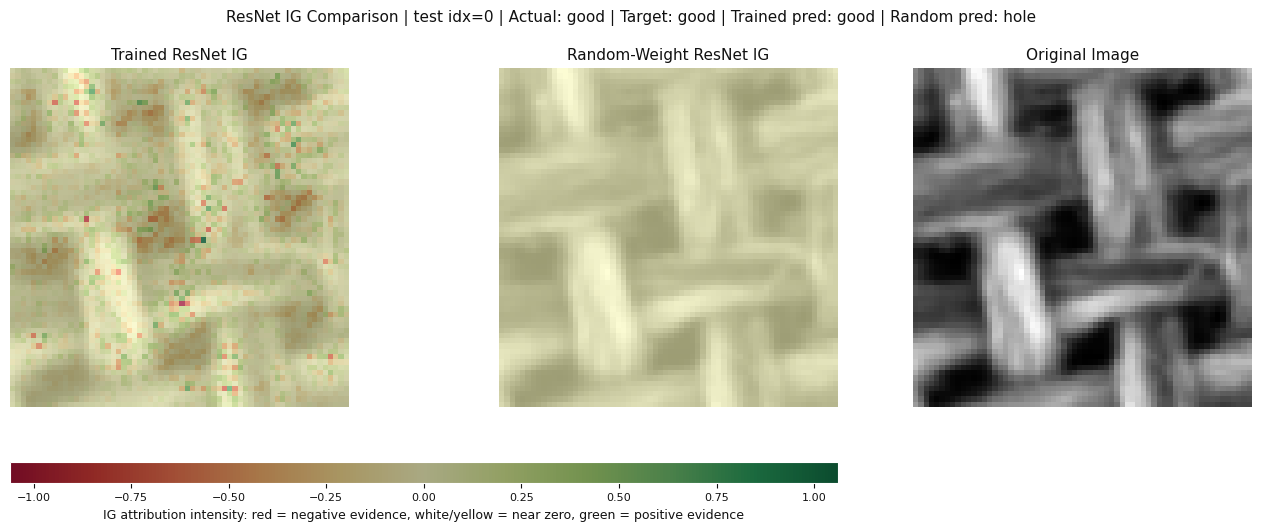

Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_color_idx_8000.png


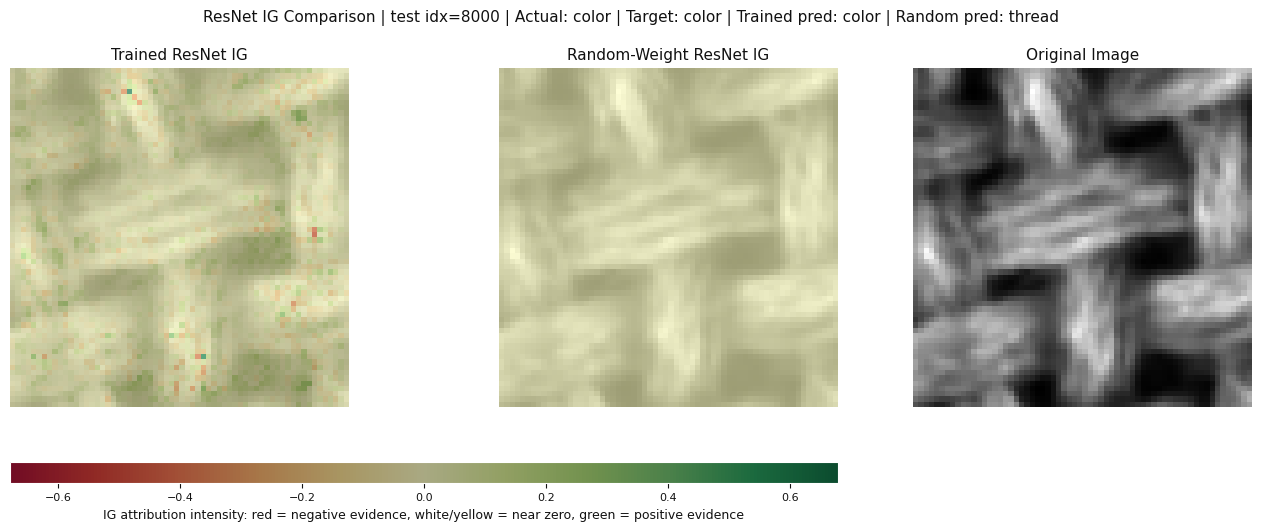

Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_cut_idx_15945.png


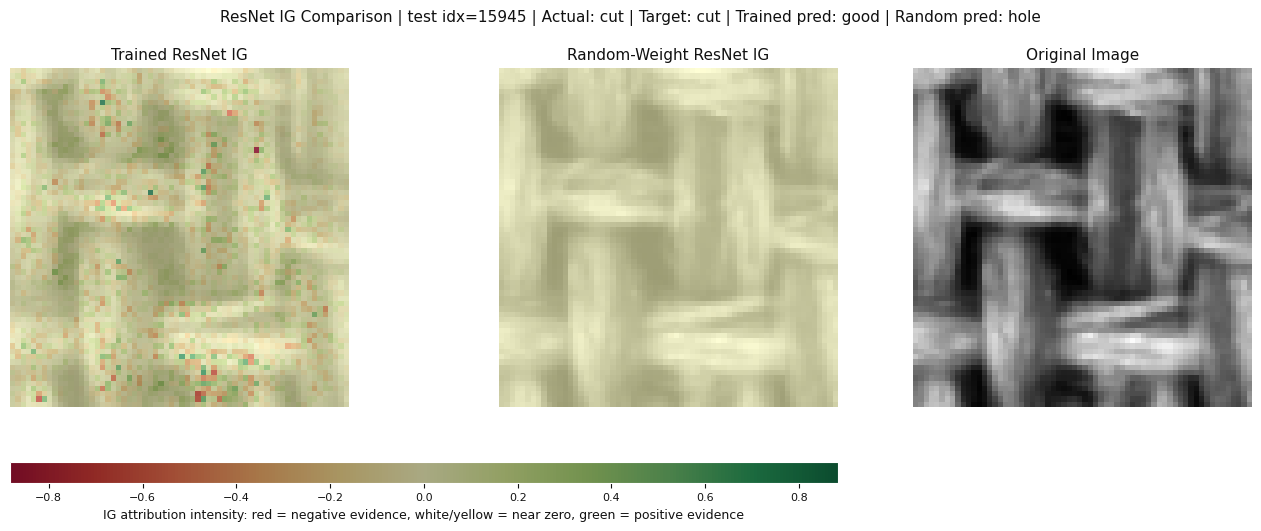

Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_hole_idx_23929.png


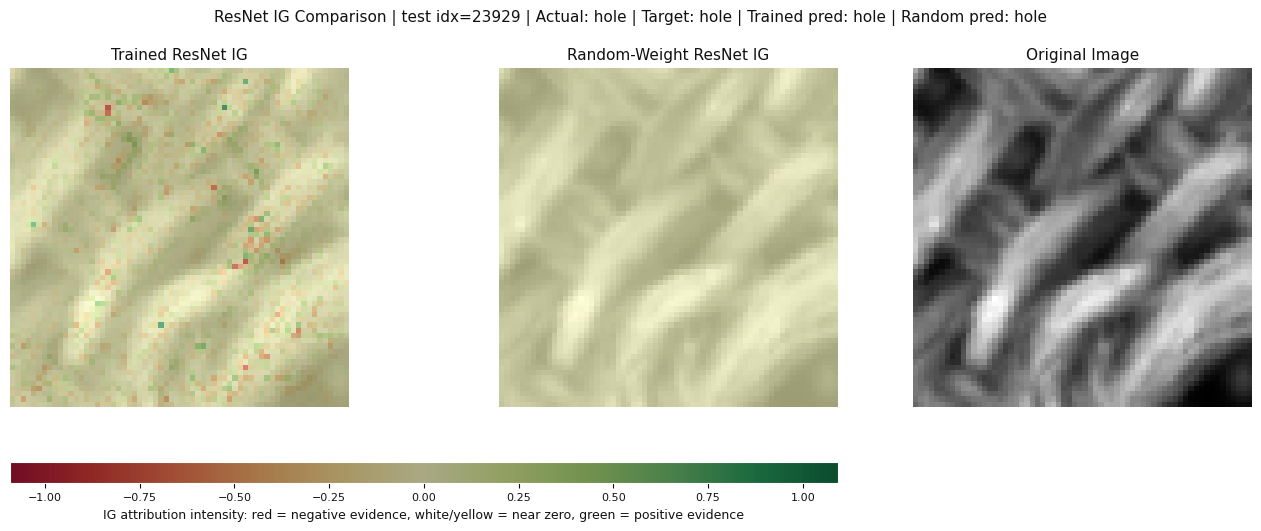

Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_thread_idx_39792.png


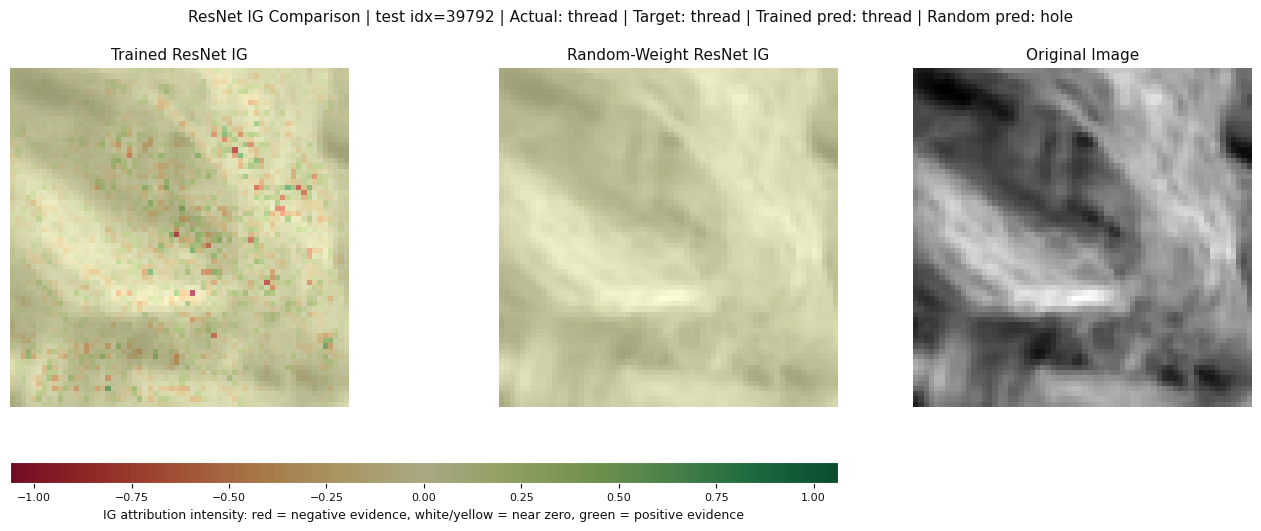

Saved ResNet IG comparison: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch\resnet_ig_comparison_test_metal_contamination_idx_31908.png


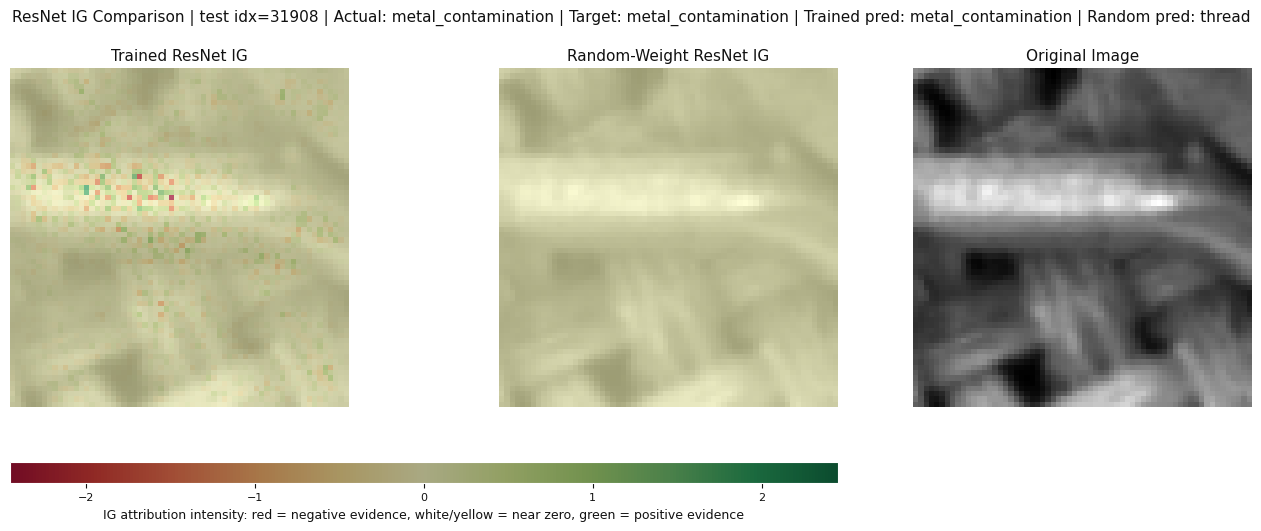

[INFO] Saved 6 ResNet IG comparison images to: C:\Download\Pycharm code\CHE1148_Defect_Detecting\data\processed\output\ResNet_pengju_branch


In [28]:
# --- Optional IG Run (Captum, offline-friendly) ---
try:
    from captum.attr import IntegratedGradients
    _captum_ready = True
except ImportError:
    IntegratedGradients = None
    _captum_ready = False
    print("[INFO] captum not installed. Skip IG demo. Install later with: pip install captum")

# Auto-run IG visualizations: first test-set image for each class.
resnet_models_obj = globals().get("resnet_models", {})
resnet_label_maps_obj = globals().get("resnet_label_maps", {})
resnet_loaders_obj = globals().get("resnet_loaders", {})
model_resnet_obj = resnet_models_obj.get(BASELINE_SCENARIO, globals().get("model_resnet"))
test_label_map_obj = resnet_label_maps_obj.get(BASELINE_SCENARIO, globals().get("train_label_map"))
test_ds_obj = None
if BASELINE_SCENARIO in resnet_loaders_obj:
    test_ds_obj = resnet_loaders_obj[BASELINE_SCENARIO].get("test_ds")
if test_ds_obj is None and test_label_map_obj is not None:
    try:
        test_ds_obj, _, _ = make_filtered_test_dataset_and_loader(
            test_label_map_obj,
            TRAIN_CFG["batch"],
            split_tag=f"resnet_{BASELINE_SCENARIO}_ig",
        )
    except Exception as e:
        print(f"[WARN] Could not build test dataset for IG: {e}")
test_ds_ready = isinstance(test_ds_obj, Sized) and len(test_ds_obj) > 0

if not _captum_ready:
    print("[INFO] IG demo skipped because captum is unavailable.")
elif model_resnet_obj is not None and test_label_map_obj is not None and test_ds_ready:
    try:
        saved_ig_files = run_resnet_ig_pengju_comparison(
            model_resnet_obj,
            test_ds_obj,
            test_label_map_obj,
            device,
            output_dir=PENGJU_RESNET_IG_OUTPUT_DIR,
        )
        print(f"[INFO] Saved {len(saved_ig_files)} ResNet IG comparison images to: {PENGJU_RESNET_IG_OUTPUT_DIR}")
    except Exception as e:
        print(f"[WARN] IG demo skipped due to error: {e}")
else:
    print("[INFO] IG prerequisites not ready. Run ResNet training cell first.")
